# The objective  
To quantify the impact of COVID-19 on unemployment rates across regions in India, and model key predictors of unemployment using labour participation and temporal trends.

# My research questions  
1. What variables significantly affect unemployment?
2. Are there temporal or demographic patterns?
3. Can we predict unemployment levels?

In [1]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind,f_oneway
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
import os
os.makedirs("results/figures",exist_ok=True)
%matplotlib inline

These libraries allows one to:
Manipulate data.
Perform statistical summaries.
Produce professional visualizations

In [2]:
#Configuring visualization style
sns.set_theme(style="whitegrid",palette="muted")

In [3]:
# loading dataset
df=pd.read_csv("Unemployment_in_India.csv")
df.head()

,Unnamed: 0,date,region,frequency,estimated unemployment rate (%),estimated employed,estimated labour participation rate (%),area,year,month,COVID_Impact,Rolling_Unemployment,diff
0,0,2019-05-31,Andhra Pradesh,Monthly,3.65,11999139.0,43.24,Rural,2019.0,May,0,NaN,NaN
1,29,2019-05-31,Madhya Pradesh,Monthly,3.91,6692720.0,38.96,Urban,2019.0,May,0,NaN,0.26
2,30,2019-05-31,Tamil Nadu,Monthly,0.97,15844698.0,49.44,Rural,2019.0,May,0,2.843333,-2.94
3,31,2019-05-31,Rajasthan,Monthly,4.03,15226005.0,38.52,Rural,2019.0,May,0,2.970000,3.06
4,32,2019-05-31,Punjab,Monthly,9.17,6088547.0,44.79,Rural,2019.0,May,0,4.723333,5.14


In [4]:
df=pd.read_csv("Unemployment_in_India.csv")

# The elements of dataset  
1. estimated unemployment rates.
2. estimated employed.
3. estimated labour participation rates
 across different regions and time periods .

In [5]:
# cleaning columns, removing leading or trailing spaces
df.columns=df.columns.str.lower().str.strip()

In [6]:
df.shape

(740, 13)

The dataset contains 768 rows and 7 columns

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 13 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   unnamed: 0                               740 non-null    int64  
 1   date                                     740 non-null    object 
 2   region                                   740 non-null    object 
 3   frequency                                740 non-null    object 
 4   estimated unemployment rate (%)          740 non-null    float64
 5   estimated employed                       740 non-null    float64
 6   estimated labour participation rate (%)  740 non-null    float64
 7   area                                     740 non-null    object 
 8   year                                     740 non-null    float64
 9   month                                    740 non-null    object 
 10  covid_impact                             740 non-n

In [8]:
 df.isnull().sum()

unnamed: 0                                 0
date                                       0
region                                     0
frequency                                  0
estimated unemployment rate (%)            0
estimated employed                         0
estimated labour participation rate (%)    0
area                                       0
year                                       0
month                                      0
covid_impact                               0
rolling_unemployment                       2
diff                                       1
dtype: int64

In [9]:
df.describe()

,unnamed: 0,estimated unemployment rate (%),estimated employed,estimated labour participation rate (%),year,covid_impact,rolling_unemployment,diff
count,740.000000,740.000000,7.400000e+02,740.000000,740.000000,740.000000,738.000000,739.000000
mean,369.500000,11.787946,7.204460e+06,42.630122,2019.418919,0.275676,11.797204,0.008403
std,213.763888,10.721298,8.087988e+06,8.111094,0.493716,0.447156,7.174968,13.906766
min,0.000000,0.000000,4.942000e+04,13.330000,2019.000000,0.000000,1.686667,-71.430000
25%,184.750000,4.657500,1.190404e+06,38.062500,2019.000000,0.000000,6.925833,-7.310000
50%,369.500000,8.350000,4.744178e+06,41.160000,2019.000000,0.000000,10.305000,-0.130000
75%,554.250000,15.887500,1.127549e+07,45.505000,2020.000000,1.000000,14.423333,7.155000
max,739.000000,76.740000,4.577751e+07,72.570000,2020.000000,1.000000,47.030000,61.750000


In [10]:
# standardize string data
df["region"]=df["region"].str.strip()
df["area"]=df["area"].str.strip()

In [11]:
# correcting data formatting ,dayfirst is critical for international date format
df["date"] = pd.to_datetime(df["date"],dayfirst=True)
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month_name()

C:\Users\user\AppData\Local\Temp\ipykernel_16080\3195950278.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"],dayfirst=True)


In [12]:
# set date as the index in the DataFrame
df.set_index("date", inplace = True)

In [13]:
# sort dataframe by index , date
df=df.sort_index()

In [14]:
# sort dataframe explicitly by the date column
df=df.sort_values("date")

In [15]:
# reset the index of the dataframe to ensure date is a column again ,not the index
df.reset_index(inplace=True)

In [16]:
# dropping rows where all values are NaN 
df=df.dropna(how="all")
# dropping remaining records with missing data
df=df.dropna()

In [17]:
# checking column names in the dataset
df.columns

Index(['date', 'unnamed: 0', 'region', 'frequency',
       'estimated unemployment rate (%)', 'estimated employed',
       'estimated labour participation rate (%)', 'area', 'year', 'month',
       'covid_impact', 'rolling_unemployment', 'diff'],
      dtype='object')

In [18]:
# print total number of records after cleaning
print(f"Cleaned Unemployment Dataset. Total Records:{len(df)}")

Cleaned Unemployment Dataset. Total Records:738


In [19]:
# create new column COVID_Impact as a binary flag
df["COVID_Impact"]=(df["date"] >= "2020-03-01").astype(int)

Exploratory Data Analysis help us to answer: 
1. When did unemployment increase?
2. Which regions had higher unemployment?

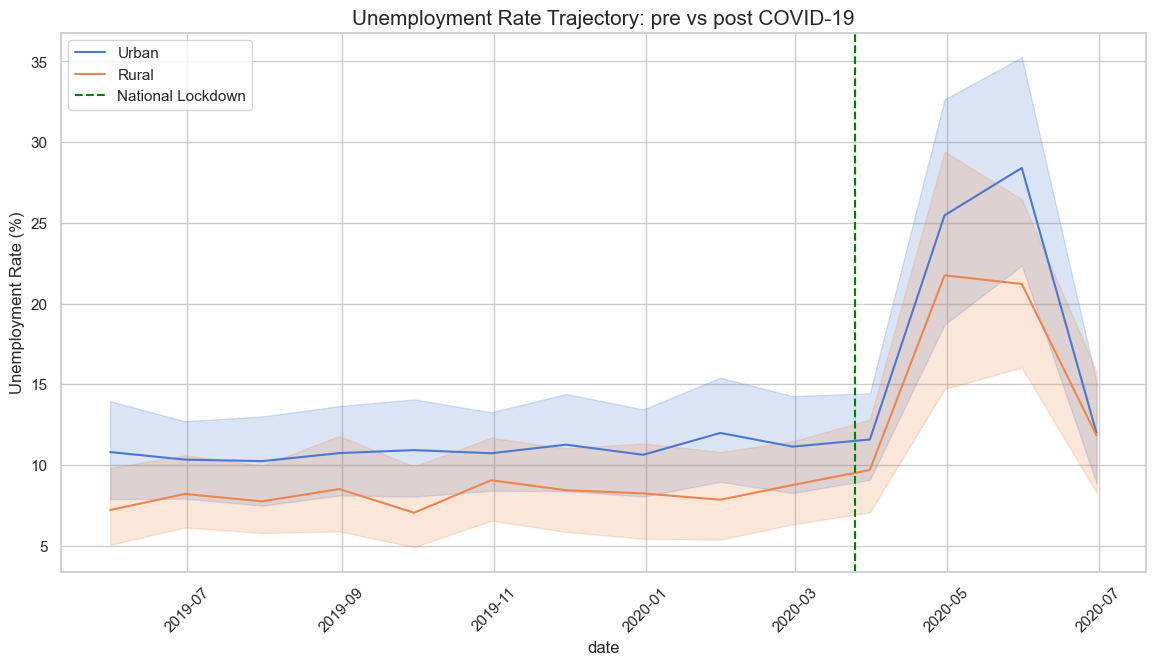

In [20]:
# plot Unemployment Rate Trajectories by area(Rural vs Urban)
plt.figure(figsize=(14,7))
sns.lineplot(x="date",y="estimated unemployment rate (%)",hue="area",data=df)
# Rotate x-axis label for better readability
plt.xticks(rotation=45)
# adding vertical line marking the national lockdown date
plt.axvline(pd.Timestamp("2020-03-25"),color="green",linestyle="--",label="National Lockdown")
plt.title("Unemployment Rate Trajectory: pre vs post COVID-19",fontsize=15)
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.savefig("results/figures/Unemployment Rate Trajectory: pre vs post COVID-19.png",dpi=300,bbox_inches="tight")
plt.show()

A structural upward shift is visually observed around March 2020, conciding with the onset of COVID-19.This suggest a potential intervention effect.

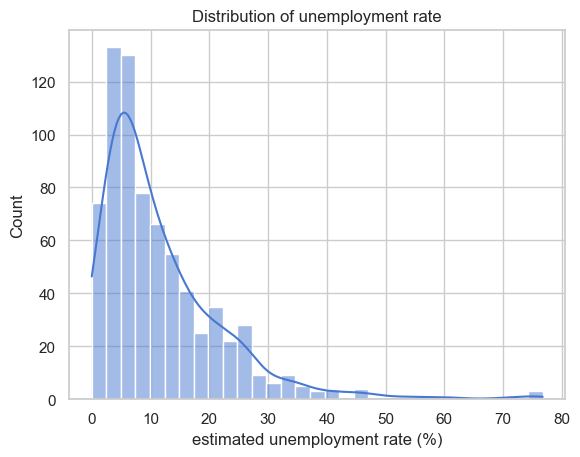

In [21]:
sns.histplot(df["estimated unemployment rate (%)"],kde=True)
plt.title("Distribution of unemployment rate")
plt.savefig("results/figures/Distribution of Unemployment Rate.png",dpi=300,bbox_inches="tight")
plt.show()

The distribution is right skewed, suggesting most regions have low unemployment but a few extreme cases exit.

Unemployment rate increased significantly during early 2020, coinciding with pandemic lockdown periods. 

In [22]:
# Sum of top 10 regions with highest unemployment during COVID
region_mean=df.groupby("region")["estimated unemployment rate (%)"].sum().sort_values(ascending=False)
print(region_mean.head(10))

region
Tripura             793.81
Haryana             735.93
Jharkhand           576.38
Bihar               529.71
Himachal Pradesh    519.13
Delhi               461.87
Rajasthan           393.63
Uttar Pradesh       351.44
Jammu & Kashmir     339.96
Punjab              336.87
Name: estimated unemployment rate (%), dtype: float64


In [23]:
# Mean of top 10 regions with highest unemployment during COVID
region_mean=df.groupby("region")["estimated unemployment rate (%)"].mean().sort_values(ascending=False)
print(region_mean.head(10))

region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: estimated unemployment rate (%), dtype: float64


In [24]:
# splitting dataset into covid and non_covid period
covid_period = df[df['date'] >= '2020-03-01']['estimated unemployment rate (%)']
non_covid_period = df[df['date'] < '2020-03-01']['estimated unemployment rate (%)']
#perform independent two-sample t-test
statistics, p_value = ttest_ind(covid_period, non_covid_period)
print("T-statistic:", statistics)
print("P-value:", p_value)
print("--- Hypothesis Testing (covid vs non_covid ---")
if p_value<0.05:
    print("Result: Statistically Significant increase in unemployment.")
else:
    print("Result: No statistically significant change detected.")

T-statistic: 9.935525466412194
P-value: 6.496582558166117e-22
--- Hypothesis Testing (covid vs non_covid ---
Result: Statistically Significant increase in unemployment.


Since p-value is much lower than the standard threshold of 0.05, we reject the Null Hypothesis. 
T-statistics :9.975 
1. It is a positive value indicating that the covid group has a higher mean than the non_covid group.
2. It is nearly 10 hence is very high.
3. Unemployment was much higher during COVID_Impact period


The analysis shows very strong evidence that COVID-19 had a real , measurable impact on unemployment rates. 
The difference is not only statistically significant but also likely economically meaningful, given the magnitude of t-statistic.

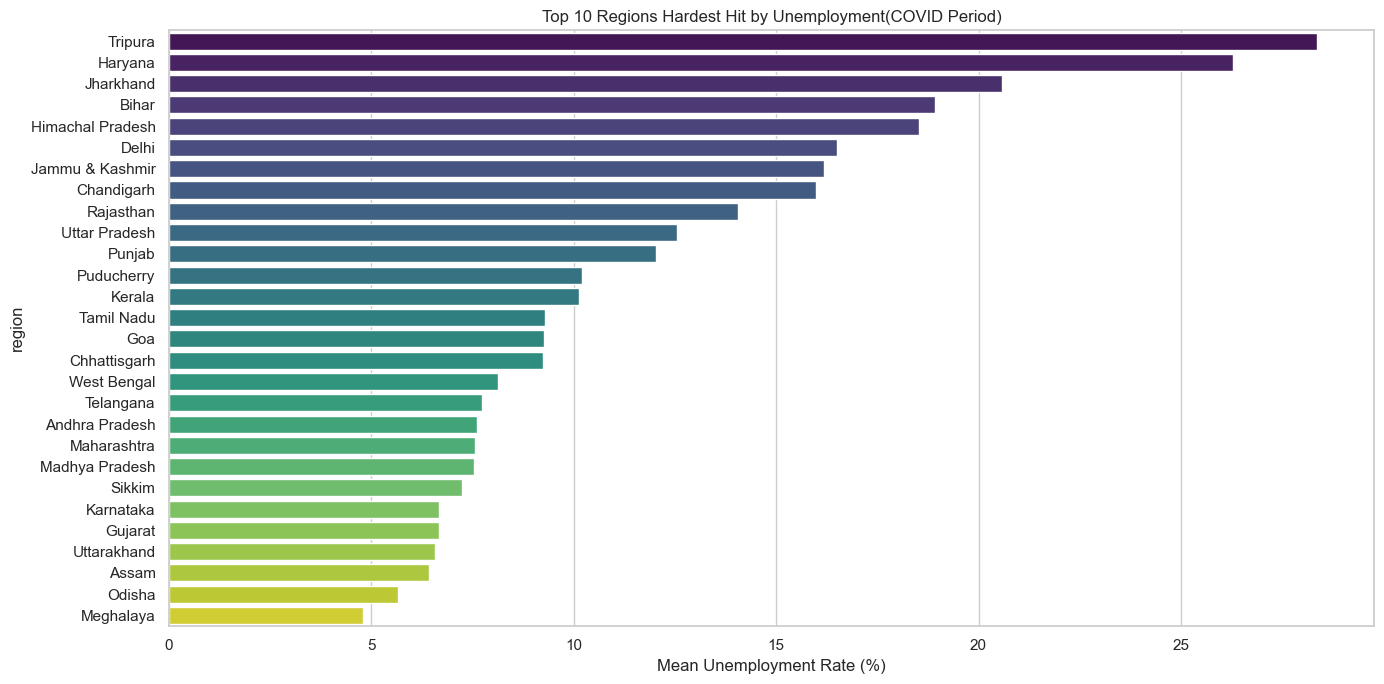

In [25]:
plt.figure(figsize=(14,7))
region_mean=region_mean.sort_values(ascending=False)
#creating a barplot of mean unemployment rates by region
sns.barplot(x=region_mean.values, y=region_mean.index, hue=region_mean.index, palette="viridis")
plt.title("Top 10 Regions Hardest Hit by Unemployment(COVID Period)")
plt.xlabel("Mean Unemployment Rate (%)")
# to avoid overlapping labels
plt.tight_layout()
plt.savefig("results/figures/Top 10 Regions Hardest Hit by Unemployment(COVID Period).png",dpi=300,bbox_inches="tight")
plt.show()

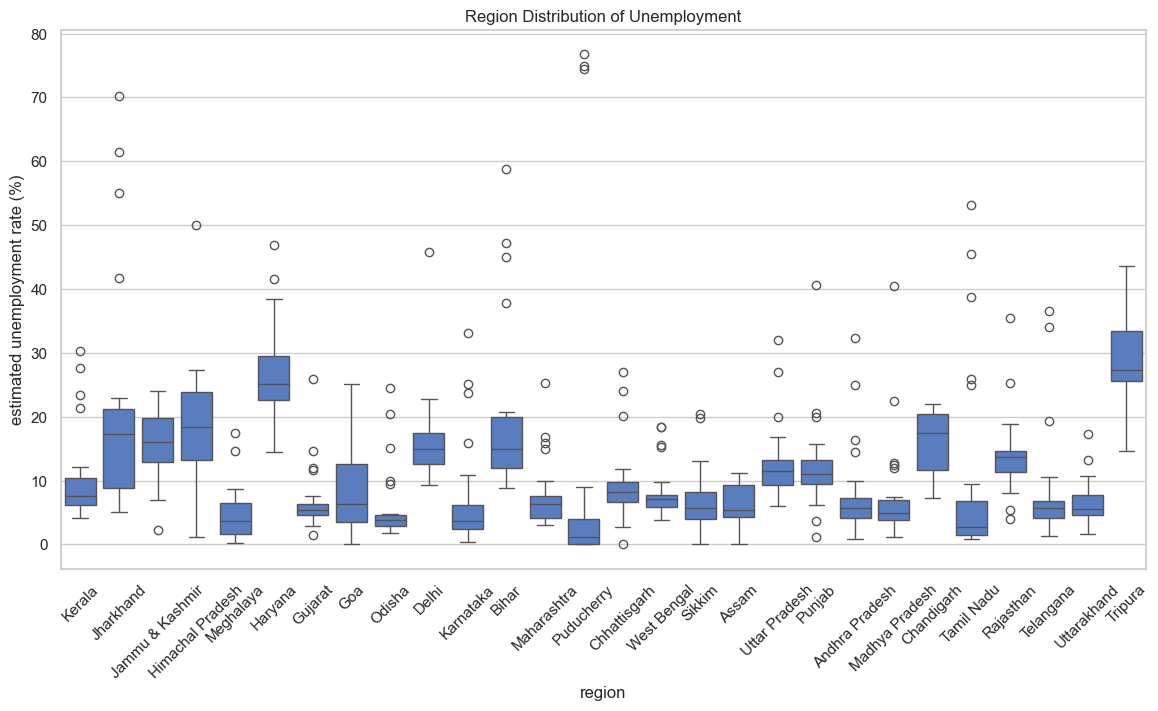

In [26]:
plt.figure(figsize=(14,7))
# create box plot to show distribution rates
sns.boxplot(x="region",y="estimated unemployment rate (%)",data=df)
plt.xticks(rotation=45)
# adding descriptive title to the plot
plt.title("Region Distribution of Unemployment")
plt.savefig("results/figures/Region Distribution of Unemployment.png",dpi=300,bbox_inches="tight")
plt.show()

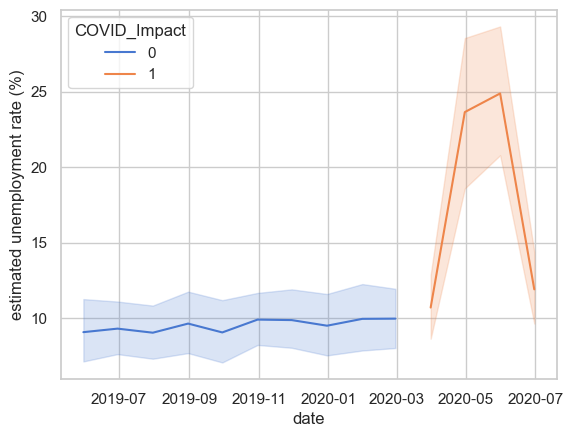

In [27]:
sns.lineplot(x="date", y="estimated unemployment rate (%)", hue = "COVID_Impact", data=df)
plt.show()

Certain regions display wider variability in unemployment, suggesting structural differences in labour markets. 
Unemployment stabilized after reopening periods.

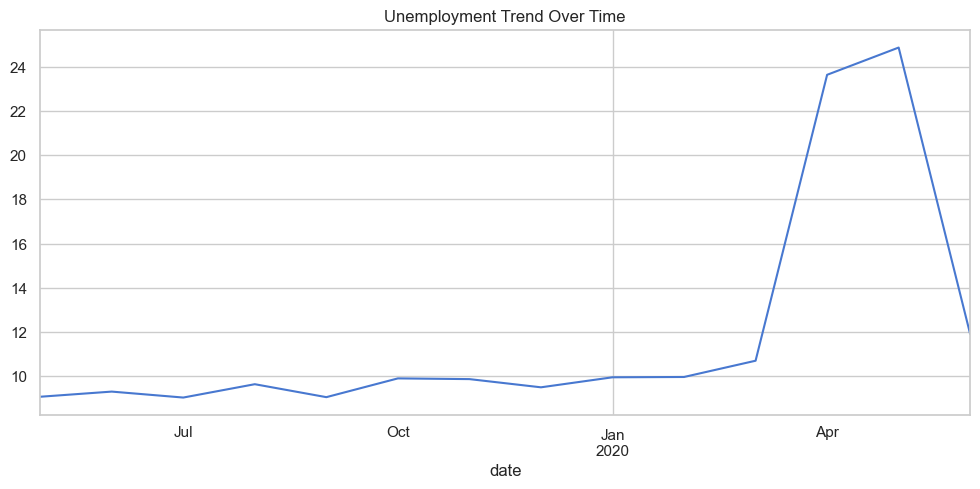

In [28]:
df.groupby("date")["estimated unemployment rate (%)"].mean().plot(figsize=(12,5))
plt.title("Unemployment Trend Over Time")
plt.savefig("results/figures/Unemployment Trend Over Time.png",dpi=300,bbox_inches="tight")
plt.show()

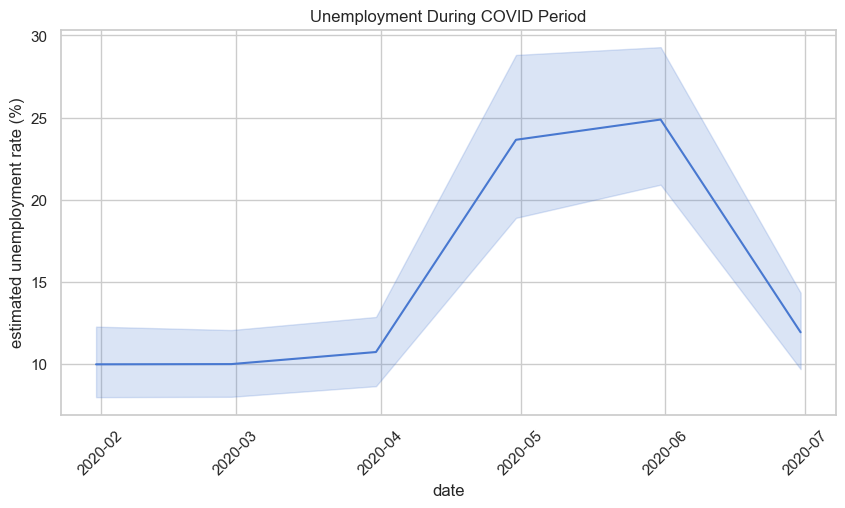

In [29]:
# filter the dataset to only include records from the year 2020
covid_period=df[df["date"].dt.year==2020]
plt.figure(figsize=(10,5))
sns.lineplot(x="date",y="estimated unemployment rate (%)",data=covid_period)
plt.xticks(rotation=45)
plt.title("Unemployment During COVID Period")
plt.savefig("results/figures/Unemployment During COVID Period.png",dpi=300,bbox_inches="tight")
plt.show()

The unemployment rate spikes during lockdown months highlight economic distruptions caused by COVID-19 restrictions.

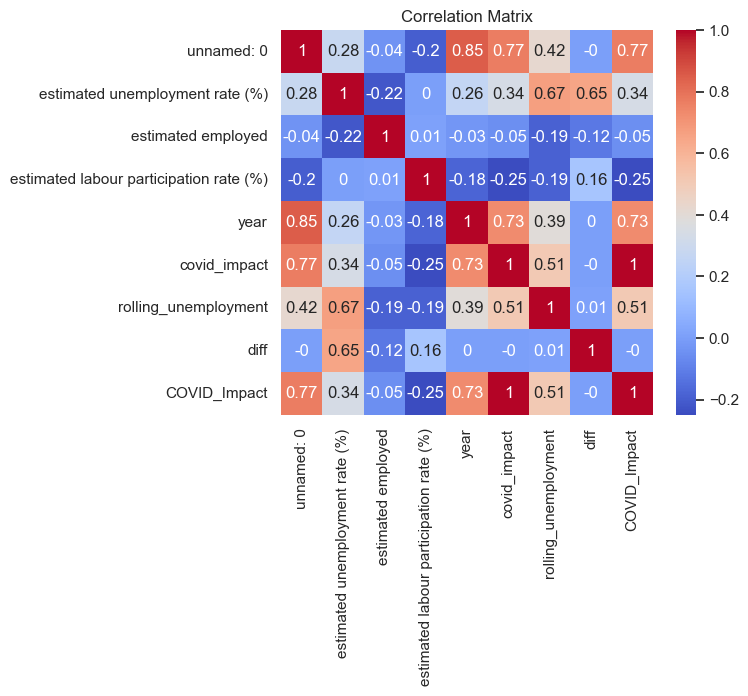

In [30]:
# compute the correlation matrix using only numeric columns
corr=df.corr(numeric_only=True)
# set the figure for heatmap
plt.figure(figsize=(6,5))
# create a heatmap of the correlation matrix
sns.heatmap(corr.round(2), annot=True, cmap="coolwarm")
# masking the upper triangle to avoid duplicate correlations
mask=np.triu(np.ones_like(corr, dtype=bool))
plt.title("Correlation Matrix")
plt.savefig("results/figures/Correlation Matrix.png",dpi=300,bbox_inches="tight")
plt.show()

# Key findings 
1. Unemployment rose sharply during early 2020.
2. Regional differences indicate structural economic variation.
3. Labour participation strongly influences employment statistics.

This analysis demonstrates how macroeconomic books such as COVID-19 pandemic significantly influenced unemployment patterns. 
The observed regional disparities suggest that economic resilience varies across regions, highlighting the need for targeted labour policies.

In [31]:
# prepare variables for OLS Regression
# model unemployment based on labour participation and COVID_Impact
X = df[["estimated labour participation rate (%)","year","COVID_Impact"]]
X = sm.add_constant(X)
y = df["estimated unemployment rate (%)"]
model = sm.OLS(y, X).fit()
print(model.summary())

                                   OLS Regression Results                                  
Dep. Variable:     estimated unemployment rate (%)   R-squared:                       0.127
Model:                                         OLS   Adj. R-squared:                  0.123
Method:                              Least Squares   F-statistic:                     35.58
Date:                             Fri, 03 Apr 2026   Prob (F-statistic):           1.79e-21
Time:                                     11:22:15   Log-Likelihood:                -2747.7
No. Observations:                              738   AIC:                             5503.
Df Residuals:                                  734   BIC:                             5522.
Df Model:                                        3                                         
Covariance Type:                         nonrobust                                         
                                              coef    std err          t      P>

# Interpretation of OLS results
 # The model fit(R-squared=0.128)
 The models explains about 12.8% of the variation in unemployment rates. This is relatively low, meaning most of the variation is driven by other factors not included in the model.
# Labour participation rate(%)
coefficient:0.1258, P_value:0.008(statistically significant at 5% level). A higher labour participation rate is associated with a slight increase in unemployment. this could reflect structural issues where more people enter the labour force but jobs are insufficient.
# COVID impact
coefficient:8.3897, P_value:0.000. The p_value is below the standard alpha level of 0.05. We can reject the null hypothesis and conclude that COVID-19 has statistically significant effect on unemployment.

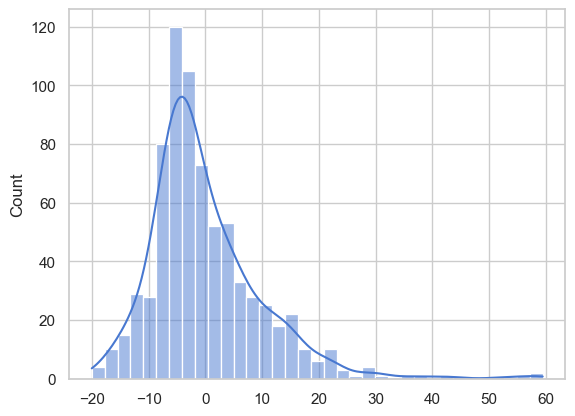

In [32]:
# extract residuals from the fitted regression model
residuals=model.resid
# plot a histogram
# this helps assess whether residuals are approximately distributed
sns.histplot(residuals, kde=True)
plt.savefig("results/figures/Distribution of residuals.png",dpi=300,bbox_inches="tight")
plt.show()

The residuals are normally distributed(bell shaped), and are centered around zero.

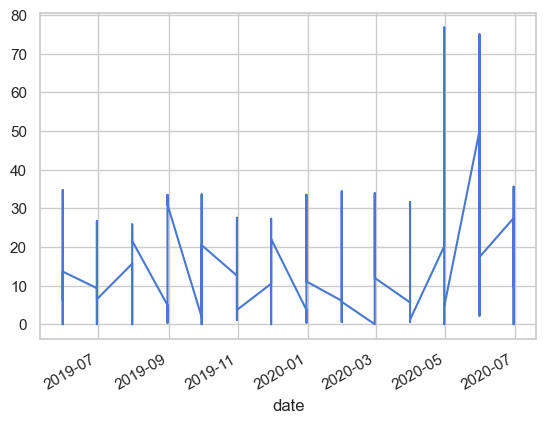

In [33]:
df.set_index("date", inplace=True)
df["estimated unemployment rate (%)"].plot()
plt.show()

In [34]:
# reset the index of the dataframe to ensure date is a column ,not the index
df.reset_index(inplace=True)

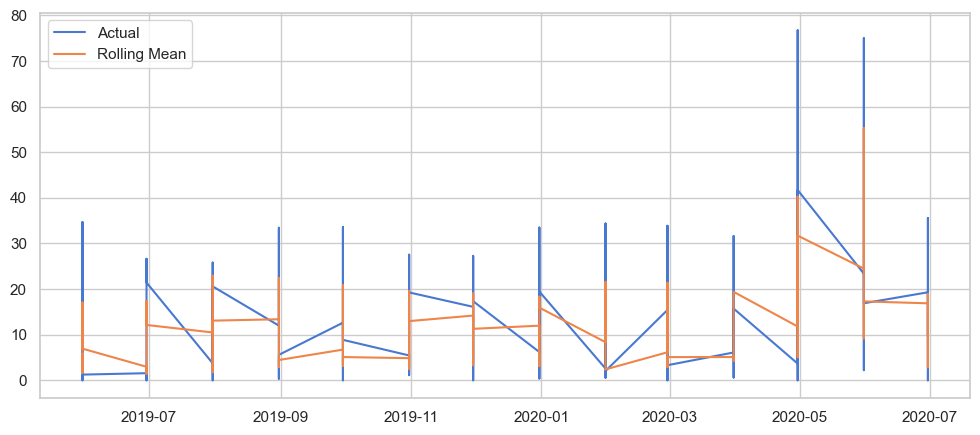

In [35]:
# sort dataframe by date column to maintain chronological order
df = df.sort_values("date")
# Convert the 'estimated unemployment rate' column to float type for calculations
df["Rolling_Unemployment"] = df["estimated unemployment rate (%)"].rolling(3).mean()
# setting figure size for the plot
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["estimated unemployment rate (%)"],label = "Actual")
plt.plot(df["date"], df["Rolling_Unemployment"], label = "Rolling Mean")
# adding legend to distinguish between the two lines
plt.legend()
plt.savefig("results/figures/Unemployment rate:Actual values vs Rolling mean(2019-2020).png",dpi=300,bbox_inches="tight")
plt.show()

In [36]:
region_mean=df.groupby("region")["estimated unemployment rate (%)"].mean().sort_values(ascending=False)
print(region_mean.head(10))

region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: estimated unemployment rate (%), dtype: float64


In [37]:
# perform one-way ANOVA to test differences in unemployment rates across regions
groups=[group["estimated unemployment rate (%)"].values for name, group in df.groupby("region")]
# run ANOVA test
f_stat, p_val=f_oneway(*groups)
print("F-stat:", f_stat)
print("P-value:", p_val)

F-stat: 13.267623135286033
P-value: 7.376138351992585e-47


The ANOVA results indicate statistically significant differences in unemployment rates across regions(p<0.05), suggesting structural regional disparities.

In [38]:
#perform Augmented Diskey-Fuller test for stationarity
result=adfuller(df["estimated unemployment rate (%)"])
print("p-value:", result[1])

p-value: 0.06484159766734972


In [39]:
# create a differenced to help achieve stationarity
df["diff"]=df["estimated unemployment rate (%)"].diff()

<Figure size 1200x500 with 0 Axes>

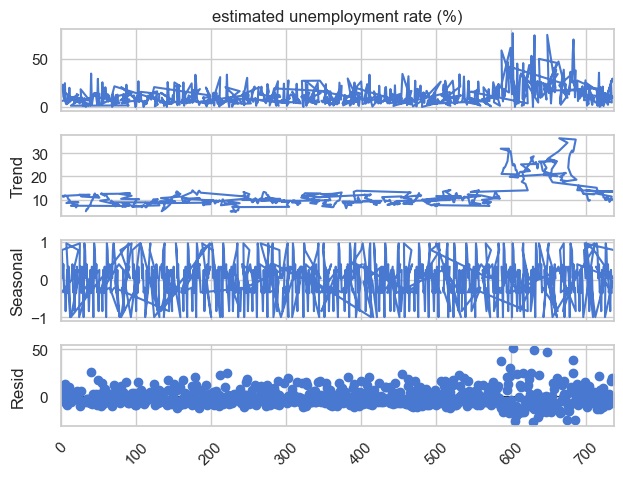

In [40]:
plt.figure(figsize=(12,5))
# seasonal decomposition of unemployment rate time series
decomp=seasonal_decompose(df["estimated unemployment rate (%)"], model="additive", period=12)
decomp.plot()
plt.xticks(rotation=45)
plt.savefig("results/figures/Seasonal decomposition of estimated unemployment rate:Trend,Seasonality, and Residuals.png",dpi=300,bbox_inches="tight")
plt.show()

# The decomposition reveals
1. Trend: Long term increase/decrease.
2. Seasonality: Recurring monthly fluctuations.
3. Residual: It is just random noise.

Unemployment varies significantly across regions, and the series shows seasonal patterns.

In [41]:
# fit an ARIMA model to the unemployment rate time series
model=ARIMA(df["estimated unemployment rate (%)"],order=(1,1,1))
# train the model on the data
results=model.fit()
# forecast unemployment rate for the next 12 time steps
forecast=results.forecast(steps=12)
print(forecast)

738    11.105038
739    11.037656
740    11.041303
741    11.041106
742    11.041116
743    11.041116
744    11.041116
745    11.041116
746    11.041116
747    11.041116
748    11.041116
749    11.041116
Name: predicted_mean, dtype: float64


C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will

The ARIMA(1,1,1) model captures short-terms dynamics in the unemployment series.
The ARIMA model captures temporal dependencies and provides short term forecasts. 
The forecasted values show unemployment stabilizing around ~12.26 after afew steps suggesting the model expects rates to level off